# How to Train a Neural Network to Detect Fraudulent Credit Card Transactions

## Introduction

### Abstract

### Learning Objectives

## Table of Contents

## Imports

In [1]:
import pandas as pd
import numpy as np
import torch
from torch import nn
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

## Data Loading and Exploration

In [4]:
# Import dataset as pandas df
df = pd.read_csv("./data/creditcard.csv")

# calculate how much is fraudulent or not, and %
num_of_non_fraudulent_transactions = len(df[df["Class"] == 0])
num_of_fraudulent_transactions = len(df[df["Class"] == 1])
percentage_of_fraudulent_transactions = num_of_fraudulent_transactions / len(df) * 100

# print out some stats
print("Null values in dataset:", df.isnull().values.any())
print("Total transactions:", len(df))
print("Number of non-fraudulent transactions:", num_of_non_fraudulent_transactions)
print("Number of fraudulent transactions:", num_of_fraudulent_transactions)
print("Percentage of fraudulent transactions:", percentage_of_fraudulent_transactions)

Null values in dataset: False
Total transactions: 284807
Number of non-fraudulent transactions: 284315
Number of fraudulent transactions: 492
Percentage of fraudulent transactions: 0.1727485630620034


In [5]:
def convert_to_df(tensor) -> pd.DataFrame:
    return pd.DataFrame(tensor.cpu().numpy())

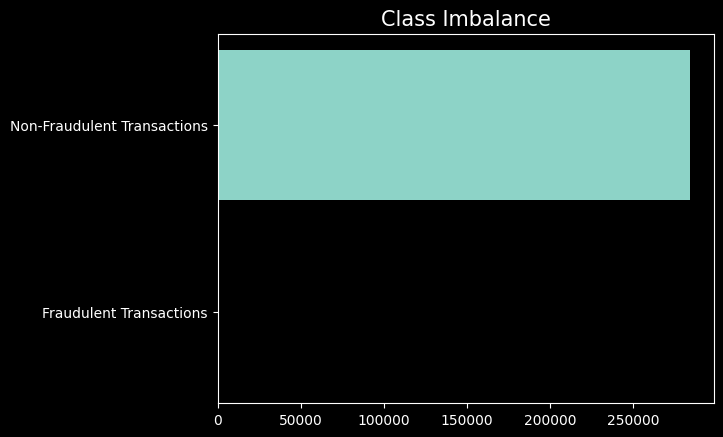

In [6]:
# display the class imbalance visually
x = np.array(["Fraudulent Transactions", "Non-Fraudulent Transactions"])
y = np.array([num_of_fraudulent_transactions, num_of_non_fraudulent_transactions])
plt.title('Class Imbalance', fontsize=15)
plt.barh(x,y)
plt.show()

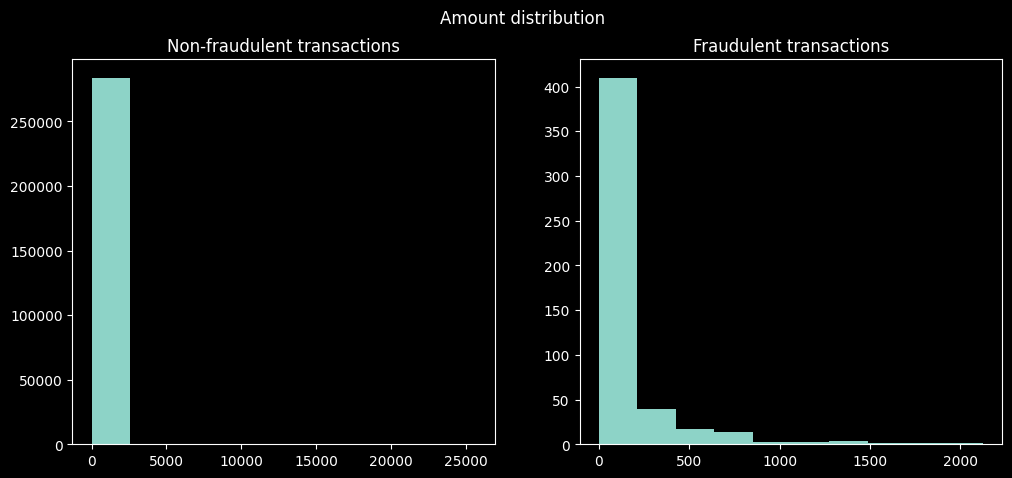

In [238]:
# for each class, display the amounts as a bar chart to show how the distribution
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
data_1 = df[df["Class"] == 0].Amount
ax1.hist(data_1)
ax1.set_title("Non-fraudulent transactions")
fig.suptitle("Amount distribution")
data_2 = df[df["Class"] == 1].Amount
ax2.hist(data_2)
ax2.set_title("Fraudulent transactions")
plt.show()

## Preprocessing

In [7]:
# split data into features and labels, then into train and test sets
features = df.drop("Class", axis=1)
label = df["Class"]
X_train, X_test, y_train, y_test = train_test_split(features, label, test_size=0.33, random_state=42)
scaler = StandardScaler()

# most features are already normalized, so only normalize amount (time is irrelevant, could drop, doesn't matter)
X_train[['Amount']] = scaler.fit_transform(X_train[['Amount']])
X_test[['Amount']] = scaler.transform(X_test[['Amount']])

# Use GPU if available (MPS for Apple Silicon, CUDA for NVIDIA, otherwise CPU)
device = torch.device("mps" if torch.backends.mps.is_available() else "cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# convert dataframes into tensors and move to device once upfront to avoid per-batch transfer overhead
X_train_tensor = torch.tensor(X_train.values).float().to(device)
X_test_tensor = torch.tensor(X_test.values).float().to(device)
y_train_tensor = torch.tensor(y_train.values).float().to(device)
y_test_tensor = torch.tensor(y_test.values).float().to(device)

# Larger batch size reduces number of batches per epoch (from ~1900 to ~47), cutting GPU kernel launch overhead
# Smoother gradients: Each update averages over more samples, so gradients are less noisy. This can make training more stable but also means the model gets fewer weight updates per epoch (47 vs 1,900).
# Class imbalance gets worse: With batch size 100, most batches had 0 fraud samples. With 4096, you'll get ~1-2 fraud samples per batch on average - still heavily dominated by non-fraud, but each update covers more data.
batch_size = 4096

# https://discuss.pytorch.org/t/what-do-tensordataset-and-dataloader-do/107017
# TensorDataset essentially zips together the features and the labels by matching indices so that they are synchronized when batching
train_dataset = torch.utils.data.TensorDataset(X_train_tensor, y_train_tensor)
validation_dataset = torch.utils.data.TensorDataset(X_test_tensor, y_test_tensor)

# DataLoader makes batching and shuffling easy when training, automatically batching the data from the tensors so memory can be used effectively
train_data_loader = torch.utils.data.DataLoader(train_dataset, batch_size)
validation_data_loader = torch.utils.data.DataLoader(validation_dataset, batch_size)

Using device: mps


## Neural Network Model

### Config 1: Binary Cross-Entropy Loss (Unweighted)

Standard Binary Cross-Entropy (BCE) [1]:

```
BCE = -[y·log(p) + (1-y)·log(1-p)]
```

- Treats all examples equally
- With 99.8% non-fraud, the model optimizes for non-fraud and ignores rare frauds
- Result: Predicts "non-fraud" for everything

[1] PyTorch Documentation: BCELoss - https://docs.pytorch.org/docs/stable/generated/torch.nn.BCELoss.html

In [240]:
# Define the Neural Network using PyTorch with one hidden layer with 128 nodes, one output node, and configurable input dimension (incase it changes)
class NeuralNetwork(nn.Module):
    def __init__(self, input_dimension):
        # Calls the parent class (nn.Module) constructor registering model with PyTorch's module system so it can track parameters, gradients, and device placement
        super().__init__()
        # Sequential chains layers together—output of one becomes input of next
        # ReLU introduces non-linearity to learn complex non-linear patterns from the data
        self.linear_relu_stack = nn.Sequential(
            nn.Linear(input_dimension, 128),
            nn.ReLU(),
            nn.Linear(128, 128),
            nn.ReLU(),
            nn.Linear(128, 1),
            nn.Sigmoid(), # BCELoss expects probabilities in [0, 1], so Sigmoid squashes output to valid range
        )

    # Sequential automatically chains layers when you call it, so no need for manual layer calls
    def forward(self, x):
        probabilities = self.linear_relu_stack(x)
        return probabilities

In [241]:
# Define loss function to be used in all configurations

def loss_batch(model, loss_function, xb, yb, opt=None):
    # Forward pass: get predictions, compute loss
    # Reshape yb to [batch_size, 1] to match model output shape
    loss = loss_function(model(xb), yb.view(-1, 1))

    # If optimiser provided, we're training (not validating)
    if opt is not None:
        loss.backward() # Compute gradients via backpropagation
        opt.step() # Update weights using gradients
        opt.zero_grad() # Clear gradients for next batch otherwise the next backward call would add to existing gradients instead of replacing

    # Return scalar loss and batch size
    return loss.item(), len(xb)

In [242]:
def train(epochs, model, loss_function, optimiser, train_data_loader, validation_data_loader):
    for epoch in range(epochs):
        # Set model to training mode
        model.train()

        # Process batches using vectorised operations
        for x_batch, y_batch in train_data_loader:
            # Process each training batch
            # optimiser is passed, so loss_batch will: compute loss, compute gradients, update weights, clear gradients
            loss_batch(model, loss_function, x_batch, y_batch, optimiser)


        # Validation phase
        # Set model to evaluation mode
        model.eval()

        # Disable gradient computation to reduce computation (good practice, wouldn't affect outcome regardless as gradients aren't computed on validation phase - no optimiser)
        with torch.no_grad():
            # For each validation batch, compute loss (no weight updates since opt=None)
            losses, nums = zip(
                *[loss_batch(model, loss_function, xb, yb) for xb, yb in validation_data_loader]
            )

        # Compute weighted average loss across all validation batches
        # Why weighted? Last batch might be smaller, so weight by batch size
        val_loss = np.sum(np.multiply(losses, nums)) / np.sum(nums)

        print(epoch, val_loss)

In [243]:
# Instantiate the Neural Network with input dimensions taken from the tensor
model = NeuralNetwork(X_train_tensor.shape[1]).to(device)

# Adam optimizer: automatically adjusts learning rates and updates weights to minimize loss
# lr=0.001 is the base learning rate (step size for weight updates)
optimiser = torch.optim.Adam(model.parameters(), lr=0.001)

# Binary Cross-Entropy loss function - standard for binary classification problems
# BCE gradients are proportional to the prediction error. MSE gradients can be very small when the model is confidently wrong (saturated sigmoid), slowing learning.
loss_function = nn.BCELoss()

# Run training with defined hyperparameters
train(10, model, loss_function, optimiser, train_data_loader, validation_data_loader)

0 0.1583965615205256
1 0.15853758758786132
2 0.15853514129812346
3 0.15853414836554866
4 0.1585336661860609
5 0.1585333999320677
6 0.15853323271157194
7 0.15853312069007477
8 0.1585330411385768
9 0.15853298334197827


In [244]:
# Save reference to Config 1 model
model_config1 = model

## Config 2: BCEWithLogitsLoss + Oversampling

```
Weighted BCE = pos_weight · y · BCE
```

- Multiplies fraud samples' loss by a weight (you used 10)
- Problem: Creates huge gradient spikes when fraud appears
- Makes training unstable (saw the wild loss jumps)

[2] PyTorch Documentation: BCEWithLogitsLoss - https://docs.pytorch.org/docs/stable/generated/torch.nn.modules.loss.BCEWithLogitsLoss.html

In [ ]:
# Define the Neural Network using PyTorch with one hidden layer with 128 nodes, one output node, and configurable input dimension (incase it changes)
class NeuralNetwork(nn.Module):
    def __init__(self, input_dimension):
        # Calls the parent class (nn.Module) constructor registering model with PyTorch's module system so it can track parameters, gradients, and device placement
        super().__init__()
        # Sequential chains layers together—output of one becomes input of next
        # ReLU introduces non-linearity to learn complex non-linear patterns from the data
        self.linear_relu_stack = nn.Sequential(
            nn.Linear(input_dimension, 128),
            nn.ReLU(),
            nn.Linear(128, 128),
            nn.ReLU(),
            nn.Linear(128, 1),
        )

    # Sequential automatically chains layers when you call it, so no need for manual layer calls
    def forward(self, x):
        logits = self.linear_relu_stack(x)
        return logits

In [ ]:
def train(epochs, model, loss_function, optimiser, train_data_loader, validation_data_loader):
    for epoch in range(epochs):
        # Set model to training mode
        model.train()

        # Process batches using vectorised operations
        for x_batch, y_batch in train_data_loader:
            # Process each training batch
            # optimiser is passed, so loss_batch will: compute loss, compute gradients, update weights, clear gradients
            loss_batch(model, loss_function, x_batch, y_batch, optimiser)

        # Validation phase
        # Set model to evaluation mode
        model.eval()

        # Disable gradient computation to reduce computation (good practice, wouldn't affect outcome regardless as gradients aren't computed on validation phase - no optimiser)
        with torch.no_grad():
            # For each validation batch, compute loss (no weight updates since opt=None)
            losses, nums = zip(
                *[loss_batch(model, loss_function, xb, yb) for xb, yb in validation_data_loader]
            )

        # Compute weighted average loss across all validation batches
        # Why weighted? Last batch might be smaller, so weight by batch size
        val_loss = np.sum(np.multiply(losses, nums)) / np.sum(nums)

        print(epoch, val_loss)
        # display the class imbalance visually
        errors.append(val_loss)


In [246]:
# Instantiate the Neural Network with input dimensions taken from the tensor
model = NeuralNetwork(X_train_tensor.shape[1]).to(device)

# Lower learning rate for stability with pos_weight
optimiser = torch.optim.Adam(model.parameters(), lr=0.0001)

# Moderate pos_weight to balance fraud detection without exploding gradients
pos_weight = torch.tensor([10.0]).to(device)

# BCEWithLogitsLoss combines sigmoid + BCE and supports class weighting
loss_function = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

# Run training with defined hyperparameters
train(100, model, loss_function, optimiser, train_data_loader, validation_data_loader)

# Save reference to Config 2 model
model_config2 = model

0 24.595315420708896
1 15.717386718724105
2 3.6165146747359875
3 9.05107859096324
4 10.992523995550998
5 0.1766203877890346
6 6.071052344369682
7 11.868141294059676
8 4.589354181601182
9 13.544185265733026
10 1.7705405884680363
11 6.116213576138969
12 12.007715004342558
13 12.468388467106603
14 2.7342741556633445
15 9.971289448078196
16 13.825455152684155
17 1.804361870122009
18 6.514319746991008
19 12.689629571643081
20 11.934891420142955
21 2.5822305293981036
22 9.672378561697567
23 14.336022192899119
24 1.8884661127712337
25 6.482006704275712
26 12.862116145569141
27 11.587301731865562
28 3.419504219755087
29 12.782368250983064
30 3.7219220195511196
31 11.289123337860417
32 15.75493833382422
33 3.2322917053886626
34 10.13008568761186
35 9.691153343748656
36 13.588321763516076
37 1.1160755501500492
38 8.583534007856954
39 13.69563302331488
40 7.81585179779876
41 4.206206624549785
42 11.400147106875618
43 1.9418304943108176
44 10.973737698927922
45 14.472176787246635
46 1.162341532053

## Config 3: Focal Loss

In [8]:
# Ref: https://arxiv.org/pdf/1708.02002
class FocalLoss(nn.Module):
    def __init__(self, alpha=0.25, gamma=2):
        super().__init__()
        self.alpha = alpha
        self.gamma = gamma

    def forward(self, inputs, targets):
        bce_loss = nn.functional.binary_cross_entropy_with_logits(inputs, targets, reduction='none')
        pt = torch.exp(-bce_loss)
        focal_loss = self.alpha * (1-pt)**self.gamma * bce_loss
        return focal_loss.mean()

In [9]:
class NeuralNetwork(nn.Module):
    def __init__(self, input_dimension):
        super().__init__()
        self.linear_relu_stack = nn.Sequential(
            nn.Linear(input_dimension, 128),
            nn.ReLU(),
            nn.Linear(128, 128),
            nn.ReLU(),
            nn.Linear(128, 1),
        )

    def forward(self, x):
        logits = self.linear_relu_stack(x)
        return logits

In [16]:
def train(epochs, model, loss_function, optimiser, train_data_loader, validation_data_loader):

    for epoch in range(epochs):
        model.train()

        for x_batch, y_batch in train_data_loader:
            loss_batch(model, loss_function, x_batch, y_batch, optimiser)

        model.eval()

        with torch.no_grad():
            losses, nums = zip(
                *[loss_batch(model, loss_function, xb, yb) for xb, yb in validation_data_loader]
            )

        val_loss = np.sum(np.multiply(losses, nums)) / np.sum(nums)

        print(epoch, val_loss)

In [17]:
# Instantiate model
model = NeuralNetwork(X_train_tensor.shape[1]).to(device)

# Optimiser
optimiser = torch.optim.Adam(model.parameters(), lr=0.001)

# Focal Loss - designed for extreme class imbalance
loss_function = FocalLoss(alpha=0.25, gamma=2)

# Train
train(100, model, loss_function, optimiser, train_data_loader, validation_data_loader)

0 4.286101378808752
1 3.9141099902656533
2 3.4193905342744793
3 2.9017744916896837
4 2.392959023268529
5 1.897462804561735
6 1.4231168832293606
7 0.9786726223038295
8 0.5418352912847273
9 0.1145546365077961
10 3.8835360557032734
11 3.454645361647114
12 2.957706598215926
13 2.5225897049844765
14 2.1407123886294777
15 1.8036382158367736
16 1.5034599853373447
17 1.232660639748612
18 0.9837073969024434
19 0.7538112118946918
20 0.5389715621849427
21 0.33420330650441493
22 0.13393127169388197
23 1.5808238122788103
24 1.8573689851142716
25 1.5763248445247309
26 1.3301773637491014
27 1.1160527799644617
28 0.9282866293006539
29 0.7622766527760029
30 0.6120573116594091
31 0.4730177862428169
32 0.3402412322359448
33 0.20864690626779417
34 0.07018923865951107
35 0.9396896025745536
36 0.8786982063980167
37 0.73074315625242
38 0.6014297919744978
39 0.48819937753157594
40 0.3880091737973843
41 0.29826702844808417
42 0.21760651033010164
43 0.1437612574827797
44 0.07174612853198424
45 0.003600171055724

In [19]:
# Save reference to Config 3 model
model_config3 = model

## Model Evaluation

In [250]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

def evaluate_model(model, data_loader, threshold=0.5):
    """Evaluate model on test set and return metrics"""
    model.eval()
    all_predictions = []
    all_labels = []

    with torch.no_grad():
        for xb, yb in data_loader:
            # Get predictions
            logits = model(xb)
            # Apply sigmoid to get probabilities
            probs = torch.sigmoid(logits)
            # Threshold to get binary predictions
            preds = (probs > threshold).float()

            all_predictions.extend(preds.cpu().numpy().flatten())
            all_labels.extend(yb.cpu().numpy().flatten())

    # Calculate metrics
    accuracy = accuracy_score(all_labels, all_predictions)
    precision = precision_score(all_labels, all_predictions, zero_division=0)
    recall = recall_score(all_labels, all_predictions, zero_division=0)
    f1 = f1_score(all_labels, all_predictions, zero_division=0)
    cm = confusion_matrix(all_labels, all_predictions)

    return {
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1': f1,
        'confusion_matrix': cm
    }

def print_evaluation(config_name, metrics):
    """Pretty print evaluation metrics"""
    print(f"\n{'='*50}")
    print(f"{config_name}")
    print(f"{'='*50}")
    print(f"Accuracy:  {metrics['accuracy']:.4f}")
    print(f"Precision: {metrics['precision']:.4f}")
    print(f"Recall:    {metrics['recall']:.4f}")
    print(f"F1 Score:  {metrics['f1']:.4f}")
    print(f"\nConfusion Matrix:")
    print(f"                 Predicted")
    print(f"                 Non-Fraud  Fraud")
    print(f"Actual Non-Fraud {metrics['confusion_matrix'][0][0]:>6}    {metrics['confusion_matrix'][0][1]:>6}")
    print(f"Actual Fraud     {metrics['confusion_matrix'][1][0]:>6}    {metrics['confusion_matrix'][1][1]:>6}")
    print(f"{'='*50}\n")

In [251]:
# Evaluate all three configurations
metrics1 = evaluate_model(model_config1, validation_data_loader)
print_evaluation("Config 1: BCELoss (Unweighted)", metrics1)

metrics2 = evaluate_model(model_config2, validation_data_loader)
print_evaluation("Config 2: BCEWithLogitsLoss + pos_weight", metrics2)

metrics3 = evaluate_model(model_config3, validation_data_loader)
print_evaluation("Config 3: Focal Loss", metrics3)


Config 1: BCELoss (Unweighted)
Accuracy:  0.9984
Precision: 0.0000
Recall:    0.0000
F1 Score:  0.0000

Confusion Matrix:
                 Predicted
                 Non-Fraud  Fraud
Actual Non-Fraud  93832         6
Actual Fraud        149         0


Config 2: BCEWithLogitsLoss + pos_weight
Accuracy:  0.9984
Precision: 0.3333
Recall:    0.0067
F1 Score:  0.0132

Confusion Matrix:
                 Predicted
                 Non-Fraud  Fraud
Actual Non-Fraud  93836         2
Actual Fraud        148         1


Config 3: Focal Loss
Accuracy:  0.9966
Precision: 0.2746
Recall:    0.7114
F1 Score:  0.3963

Confusion Matrix:
                 Predicted
                 Non-Fraud  Fraud
Actual Non-Fraud  93558       280
Actual Fraud         43       106

